In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf
from importlib import reload

In [2]:
def reload_protocols():
    reload(qsf)

## Parameters for RR

In [45]:
eta = 0.1
keylen = 1000
sigma_grid = np.linspace(0.001,10,21)
var_a_grid = sigma_grid**2
V=0.1

### Mutual Information

In [46]:
reload_protocols()
I_RR, I_x_RR, I_p_RR = qsf.MC_I_AB(var_a_grid, eta, keylen, V)

Progress: 21/21

In [47]:
reload_protocols()
th_I_RR, th_I_x_RR, th_I_p_RR = qsf.theoretical_I_AB(sigma_grid**2, eta, V)

### Holevo Bound

In [56]:
reload_protocols()
th_chi_x_RR = np.zeros((len(var_a_grid)))

for i,sigma in enumerate(sigma_grid):
    chi, chi_x, chi_p = qsf.holevo_RR(sigma**2, eta, V)
    th_chi_x_RR[i] = chi_x
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

Progress: 21/21

### Plot Mutual Information & Holevo Bound

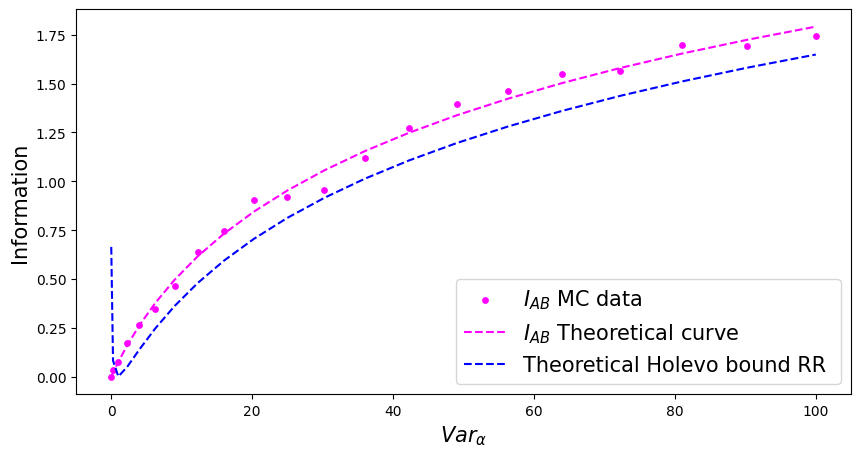

In [57]:
reload_protocols()

b = 0.95

fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(var_a_grid, I_x_RR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.plot(var_a_grid, th_I_x_RR, '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.plot(var_a_grid, th_chi_x_RR, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)



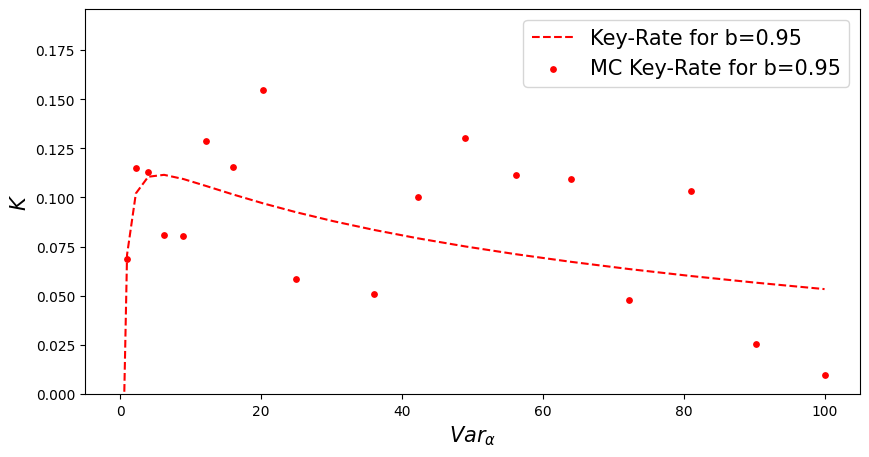

In [58]:
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(var_a_grid, qsf.key_rate(b,  th_I_x_RR, th_chi_x_RR), '--r', label = f'Key-Rate for b={b}')
plt.scatter(var_a_grid, qsf.key_rate(b, I_x_RR, th_chi_x_RR), s=15, color = 'red', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)


## Parameters for DR protocol

In [119]:
eta = 0.6
keylen = 500
sigma_grid = np.linspace(0.001,10,51)
var_a_grid = sigma_grid**2
V = 0.1

### Mutual Information

In [120]:
reload_protocols()
I_DR, I_x_DR, I_p_DR = qsf.MC_I_AB(var_a_grid, eta, keylen, V)

Progress: 51/51

In [95]:
reload_protocols()
th_I_DR, th_I_x_DR, th_I_p_DR = qsf.theoretical_I_AB(sigma_grid**2, eta, V)

### Holevo Bound

In [98]:
reload_protocols()
th_chi_x_DR = np.zeros((len(var_a_grid)))
chi_sc=[]
for i,sigma in enumerate(sigma_grid):
    chi_x, chi_p = qsf.holevo_DR(sigma**2, eta, V)
    th_chi_x_DR[i] = chi_x
    chi_sc.append(qsf.holevo_DR_SF(eta,sigma**2,V, 'x'))
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

Progress: 51/51

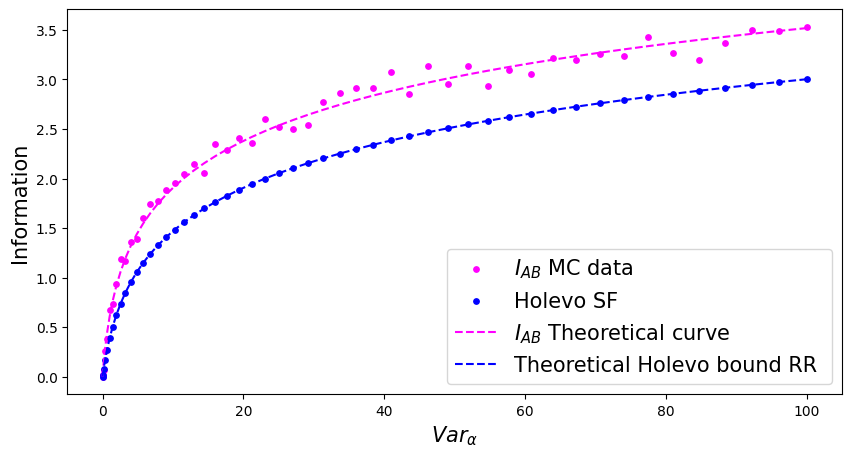

In [100]:
reload_protocols()

fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(var_a_grid, I_x_DR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.scatter(var_a_grid, chi_sc, s=15, color = 'blue', label=r'Holevo SF')
plt.plot(var_a_grid, th_I_x_DR, '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.plot(var_a_grid, th_chi_x_DR, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)

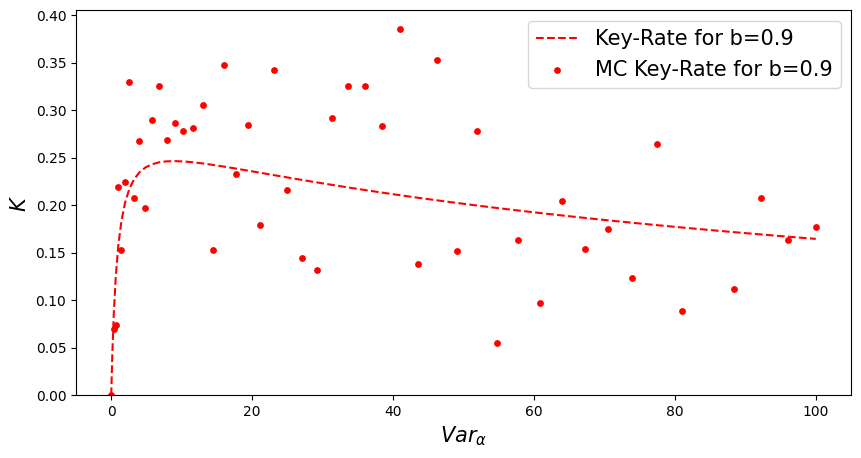

In [101]:
b = 0.9

fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(var_a_grid, qsf.key_rate(b,  th_I_x_DR, th_chi_x_DR), '--r', label = f'Key-Rate for b={b}')
plt.scatter(var_a_grid, qsf.key_rate(b, I_x_DR, th_chi_x_DR), s=15, color = 'red', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)
